In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [5]:
#selecting five columns
df = df[['engine_displacement','horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']]

df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [6]:
df.shape

(10000, 5)

In [ ]:
#checking for missing values
df.isnull().sum() #horsepower = 877 missing values

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

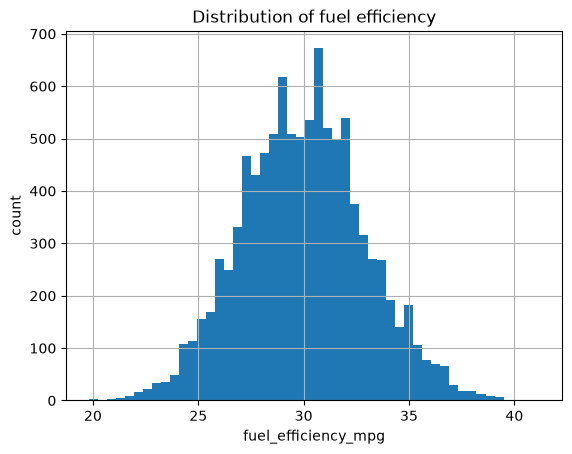

In [ ]:
#checking the skewness
import matplotlib.pyplot as plt
df['fuel_efficiency_mpg'].hist(bins = 50)
plt.xlabel('fuel_efficiency_mpg')
plt.ylabel('count')
plt.title('Distribution of fuel efficiency')
plt.show() # fuel_efficiency_mpg doesnot have a long tail

In [10]:
#horsepower median
df['horsepower'].median()

np.float64(254.0)

In [12]:
#Shuffling the filtered dataset and creating the split
import numpy as np
n = len(df) 
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]



In [13]:
#dealing with missing values
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [14]:
#filling missing value with zero
def prepare_X_zero(df):
    df_num = df.fillna(0)
    X = df_num.values
    return X

X_train = prepare_X_zero(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_zero(df_val)
y_pred = w0 + X_val.dot(w)

rmse_zero = round(rmse(y_val, y_pred), 3)
print(rmse_zero)

2.205


In [18]:
#filling missing value with mean value

def prepare_X_mean(df, mean_val):
    df_num = df.copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(mean_val)
    X = df_num.values
    return X

X_train = prepare_X_mean(df_train, mean_horsepower)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_mean(df_val, mean_horsepower)
y_pred = w0 + X_val.dot(w)

rmse_mean = round(rmse(y_val, y_pred), 3)
def prepare_X_mean(df, mean_val):
    df_num = df.copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(mean_val)
    X = df_num.values
    return X

X_train = prepare_X_mean(df_train, mean_horsepower)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_mean(df_val, mean_horsepower)
y_pred = w0 + X_val.dot(w)

rmse_mean = round(rmse(y_val, y_pred), 3)
print(rmse_mean)

2.202


In [16]:
print("RMSE (fill with 0):", rmse_zero)
print("RMSE (fill with mean):", rmse_mean)

RMSE (fill with 0): 2.205
RMSE (fill with mean): 2.202


In [19]:
#Regularized training function
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [21]:
#Preparing X (fill with 0, same as before)
X_train = prepare_X_zero(df_train)
X_val = prepare_X_zero(df_val)

In [22]:
#Loop over r values
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    print(r, score)

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [23]:

scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    # split
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    # target
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
    df_val = df_val.drop(columns=['fuel_efficiency_mpg'])

    # fill with 0, train, evaluate
    X_train = prepare_X_zero(df_train)
    X_val = prepare_X_zero(df_val)

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)

print(scores)
std = round(np.std(scores), 3)
print(std)

[np.float64(2.239204143046126), np.float64(2.2021128210838845), np.float64(2.1634197787530947), np.float64(2.2043588768539224), np.float64(2.2018800943311554), np.float64(2.2457851509085134), np.float64(2.2697212079524043), np.float64(2.190794599933443), np.float64(2.216611201686444), np.float64(2.2070365928178957)]
0.029


In [24]:
# split with seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

# targets
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

# combine train + val
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

# fill with 0, train with r=0.001
X_full_train = prepare_X_zero(df_full_train)
X_test = prepare_X_zero(df_test)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
print(round(score, 3))

2.236
